# **REINFORCE**

REINFORCE算法的具体算法流程:

- 初始化策略参数$\theta$
- for 序列$e=1 \rightarrow E$ do:
    - 用当前策略$\pi_{\theta}$采样轨迹$\left\{s_{1}, a_{1}, r_{1}, s_{2}, a_{2}, r_{2}, \ldots s_{T}, a_{T}, r_{T}\right\}$
    - 计算**当前轨迹每个时刻$t$往后的回报**$\sum_{t'=t}^{T} \gamma^{t'-t} r_{t'}$, 记为$\psi_t$
    - 对$\theta$进行更新, $\theta=\theta+\alpha \sum_{t}^{T} \psi_{t} \nabla_{\theta} \log \pi_{\theta}(a_{t} | s_{t})$
- end for

In [2]:
import gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
sys.path.append('../') # 在上层目录下
import rl_utils

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


首先定义策略网络`PolicyNet`，
- 其输入是某个状态
- 输出则是该状态下的动作概率分布
- 采用在离散动作空间上的softmax()函数来实现一个可学习的多项分布（multinomial distribution）。

In [3]:
class PolicyNet(torch.nn.Module):
    ''' 策略网络 '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim) # 全连接层
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))  # 隐藏层使用ReLU激活函数
        return F.softmax(self.fc2(x), dim=1)  # 输出动作概率分布,使用softmax函数

定义REINFORCE 算法, 主要包括采样、计算回报、更新策略等函数。

在函数take_action()函数中，通过动作概率分布对离散的动作进行采样。

在更新过程中，我照算法将损失函数写为策略回报的负数, 即$-\sum_{t} \psi_{t} \nabla_{\theta} \log \pi_{\theta}\left(a_{t} | s_{t}\right)$

对$\theta$求导后就可以通过梯度下降来更新策略。

In [4]:
class REINFORCE:
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma,
                 device):
        self.policy_net = PolicyNet(state_dim, hidden_dim,
                                    action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(),
                                          lr=learning_rate)  # 使用Adam优化器
        self.gamma = gamma  # 折扣因子
        self.device = device

    def take_action(self, state):  # 根据动作概率分布随机采样
        state = torch.tensor([state], dtype=torch.float).to(self.device) # 转为张量
        probs = self.policy_net(state) # 动作概率分布
        action_dist = torch.distributions.Categorical(probs) # 多项分布
        action = action_dist.sample() # 采样
        return action.item() # 转为整数

    def update(self, transition_dict):
        reward_list = transition_dict['rewards']
        state_list = transition_dict['states']
        action_list = transition_dict['actions']

        G = 0 # 初始化回报
        self.optimizer.zero_grad() # 梯度清零
        for i in reversed(range(len(reward_list))):  # 从最后一步算起
            reward = reward_list[i] # 当前步的奖励
            state = torch.tensor([state_list[i]],
                                 dtype=torch.float).to(self.device) # 转为张量
            action = torch.tensor([action_list[i]]).view(-1, 1).to(self.device) # 转为张量
            log_prob = torch.log(self.policy_net(state).gather(1, action)) # 计算logπ(a|s)
            G = self.gamma * G + reward # 计算当前步往后的回报
            loss = -log_prob * G  # 每一步的损失函数
            loss.backward()  # 反向传播计算梯度
        self.optimizer.step()  # 梯度下降

在Cartpole环境上

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) # 忽略CartPole-v0过时警告

learning_rate = 1e-3
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = "CartPole-v0"
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = REINFORCE(state_dim, hidden_dim, action_dim, learning_rate, gamma,
                  device)

return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):
            episode_return = 0
            transition_dict = {
                'states': [],
                'actions': [],
                'next_states': [],
                'rewards': [],
                'dones': []
            }
            state = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, done, _ = env.step(action)
                transition_dict['states'].append(state)
                transition_dict['actions'].append(action)
                transition_dict['next_states'].append(next_state)
                transition_dict['rewards'].append(reward)
                transition_dict['dones'].append(done)
                state = next_state
                episode_return += reward
            return_list.append(episode_return)
            agent.update(transition_dict)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

Iteration 9: 100%|██████████| 100/100 [01:05<00:00,  1.53it/s, episode=1000, return=180.700]


绘制训练过程

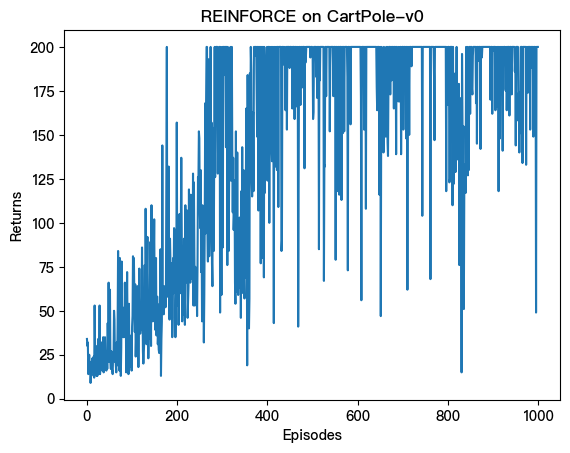

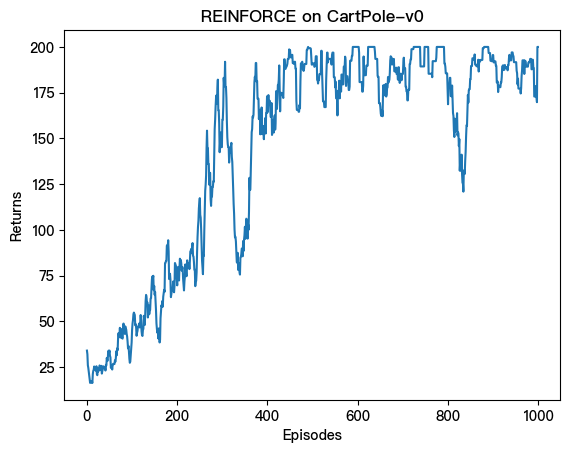

In [7]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

随着收集到的轨迹越来越多，REINFORCE 算法有效地学习到了最优策略。

相比于前面的 DQN 算法，REINFORCE 算法使用了更多的序列，这是因为 REINFORCE 算法是一个在线策略算法，之前收集到的轨迹数据不会被再次利用。

此外，REINFORCE 算法的性能也有一定程度的波动，这主要是因为每条采样轨迹的回报值波动比较大，这也是 REINFORCE 算法主要的不足。